# Olist E-Commerce Data Analysis

**Dataset:** Brazilian E-Commerce Public Dataset by Olist (Kaggle)

**Goal:** Explore multi-table e-commerce data (orders, items, products, customers, payments, reviews) to understand order patterns, revenue drivers, and what impacts customer satisfaction.

**Tools used:** pandas, numpy, seaborn, matplotlib — merging, groupby aggregation, and visualization.

## 1. Import Libraries

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## 2. Load All Tables

In [5]:
data = pd.read_csv('olist_orders_dataset.csv')
items = pd.read_csv('olist_order_items_dataset.csv')
products = pd.read_csv('olist_products_dataset.csv')
customers = pd.read_csv('olist_customers_dataset.csv')
payments = pd.read_csv('olist_order_payments_dataset.csv')
reviews = pd.read_csv('olist_order_reviews_dataset.csv')

## 3. Orders — Delivery Time Analysis

First, understand the orders table structure and check for missing values.

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [8]:
data.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

**Insight:** Missing values in `order_approved_at`, `order_delivered_carrier_date`, and `order_delivered_customer_date` are not random — they correspond to orders that never completed the full delivery lifecycle (cancelled, processing, shipped, etc.), confirmed by comparing counts against `order_status`.

In [10]:
data['order_status'].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [11]:
data['order_purchase_timestamp'] = pd.to_datetime(data['order_purchase_timestamp'])
data['order_delivered_customer_date'] = pd.to_datetime(data['order_delivered_customer_date'])
data['delivery_days'] = (data['order_delivered_customer_date'] - data['order_purchase_timestamp']).dt.days
data['delivery_days'].describe()

count    96476.000000
mean        12.094086
std          9.551746
min          0.000000
25%          6.000000
50%         10.000000
75%         15.000000
max        209.000000
Name: delivery_days, dtype: float64

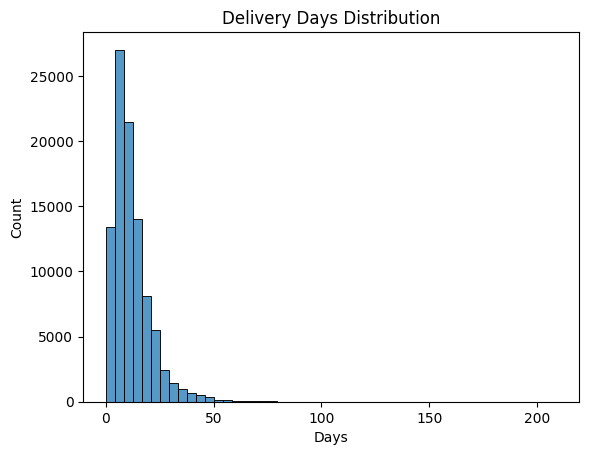

In [12]:
sns.histplot(data['delivery_days'], bins=50)
plt.title('Delivery Days Distribution')
plt.xlabel('Days')
plt.show()

**Insight:** Average delivery time is ~12 days, but the distribution is right-skewed — most orders arrive within 6–15 days, while a small number of outliers take up to 209 days.

## 4. Order Value Analysis

Merge orders with order_items to compute total value per order.

In [15]:
merged = data.merge(items, on='order_id')
merged.shape

(112650, 15)

In [16]:
order_value = merged.groupby('order_id')['price'].sum()
order_value.describe()

count    98666.000000
mean       137.754076
std        210.645145
min          0.850000
25%         45.900000
50%         86.900000
75%        149.900000
max      13440.000000
Name: price, dtype: float64

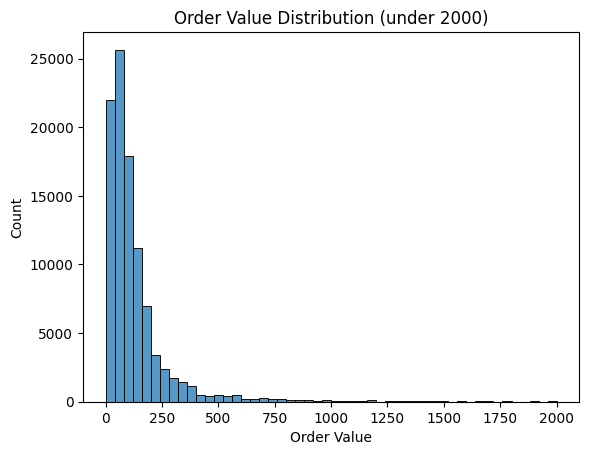

In [17]:
sns.histplot(order_value[order_value < 2000], bins=50)
plt.title('Order Value Distribution (under 2000)')
plt.xlabel('Order Value')
plt.show()

**Insight:** Median order value (~87) is well below the mean (~138), indicating a right-skewed distribution driven by a small number of high-value orders (max ~13,440).

## 5. Category-wise Revenue

Merge with products to find which categories drive the most revenue.

In [20]:
final = merged.merge(products, on='product_id')
final.shape

(112650, 23)

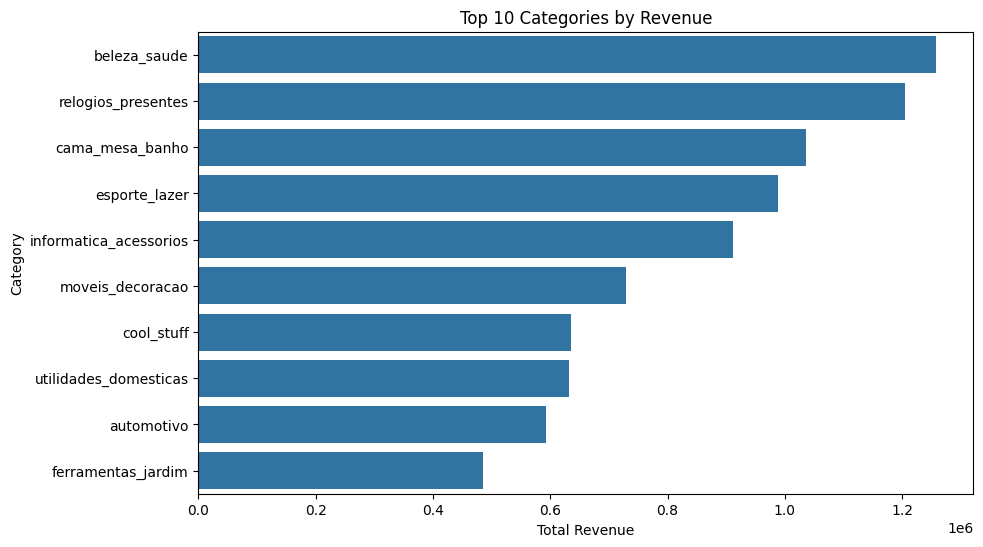

In [21]:
top10 = final.groupby('product_category_name')['price'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top10.values, y=top10.index)
plt.title('Top 10 Categories by Revenue')
plt.xlabel('Total Revenue')
plt.ylabel('Category')
plt.show()

**Insight:** `beleza_saude` (Health & Beauty) and `relogios_presentes` (Watches & Gifts) are the top two revenue-generating categories.

## 6. State-wise Revenue

Merge with customers to see revenue distribution by region.

In [24]:
final2 = final.merge(customers, on='customer_id')
final2.shape

(112650, 27)

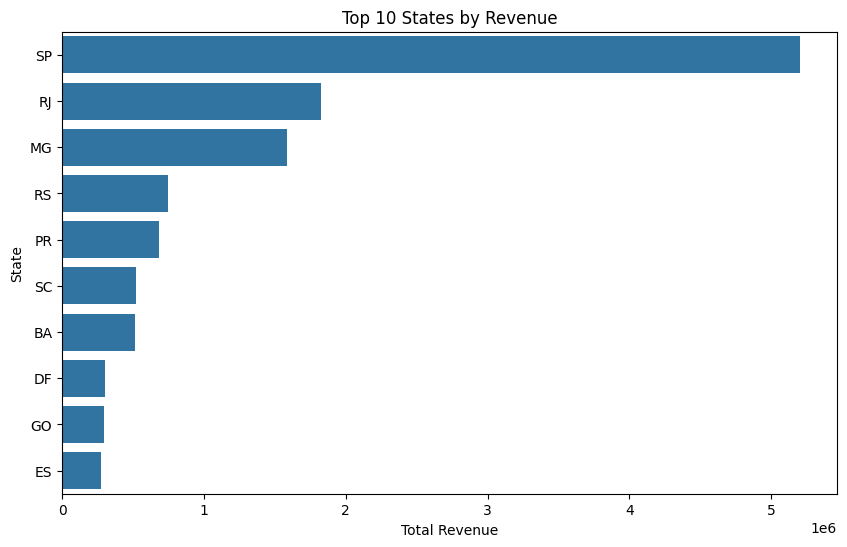

In [25]:
state_revenue = final2.groupby('customer_state')['price'].sum().sort_values(ascending=False)
top_states = state_revenue.head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_states.values, y=top_states.index)
plt.title('Top 10 States by Revenue')
plt.xlabel('Total Revenue')
plt.ylabel('State')
plt.show()

**Insight:** SP (São Paulo) alone generates roughly 3x the revenue of the next highest state (RJ), reflecting its role as Brazil's largest commercial hub.

## 7. Payment Behavior

In [28]:
payments['payment_type'].value_counts()

payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

In [29]:
payments.groupby('payment_type')['payment_value'].mean().sort_values(ascending=False)

payment_type
credit_card    163.319021
boleto         145.034435
debit_card     142.570170
voucher         65.703354
not_defined      0.000000
Name: payment_value, dtype: float64

In [30]:
payments['payment_installments'].value_counts().sort_index().head(15)

payment_installments
0         2
1     52546
2     12413
3     10461
4      7098
5      5239
6      3920
7      1626
8      4268
9       644
10     5328
11       23
12      133
13       16
14       15
Name: count, dtype: int64

**Insight:** Credit card is the dominant payment method (~74% of transactions) and also has the highest average transaction value. Most customers pay in a single installment, though a notable share opt for 10 installments specifically.

## 8. Delivery Delay vs Review Score

The key question: does a slower delivery lead to a worse review?

In [33]:
reviews['review_score'].value_counts().sort_index()

review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64

In [34]:
review_delivery = data.merge(reviews, on='order_id')
review_delivery.groupby('review_score')['delivery_days'].mean()

review_score
1    20.849825
2    16.194832
3    13.795278
4    11.848054
5    10.224097
Name: delivery_days, dtype: float64

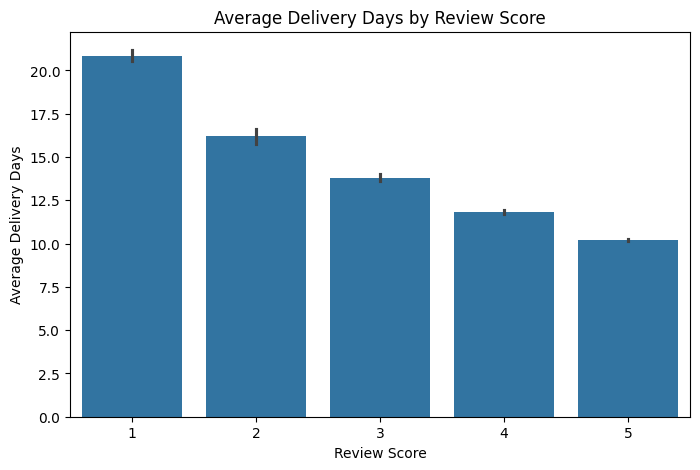

In [35]:
plt.figure(figsize=(8,5))
sns.barplot(x='review_score', y='delivery_days', data=review_delivery)
plt.title('Average Delivery Days by Review Score')
plt.xlabel('Review Score')
plt.ylabel('Average Delivery Days')
plt.show()

**Key Insight:** There is a clear, consistent negative relationship between delivery time and review score — orders with 1-star reviews took ~21 days on average to deliver, compared to just ~10 days for 5-star reviews. Delivery speed is one of the strongest drivers of customer satisfaction in this dataset.

## 9. Summary of Findings

- **Delivery:** Average delivery time is ~12 days; missing delivery dates correspond to orders that never completed the full lifecycle (cancelled/processing/shipped).
- **Order Value:** Right-skewed — median ~₹87, driven up by a few high-value orders.
- **Top Categories:** Health & Beauty and Watches & Gifts generate the most revenue.
- **Geography:** São Paulo (SP) dominates revenue, generating ~3x the next-highest state.
- **Payments:** Credit card is the most-used and highest-value payment method; most customers pay in full rather than installments.
- **Customer Satisfaction:** Delivery delay is strongly linked to lower review scores — the single clearest actionable insight in this dataset. Orders rated 1-star took roughly double the delivery time of 5-star orders.

**Tools demonstrated:** pandas (merge, groupby, aggregation, datetime handling), numpy, seaborn/matplotlib (histograms, bar charts), and structured multi-table EDA workflow.

In [38]:
review_delivery['is_good_review'] = (review_delivery['review_score'] >= 4).astype(int)
review_delivery['is_good_review'].value_counts()

is_good_review
1    76470
0    22754
Name: count, dtype: int64

In [39]:
ml_data = review_delivery.merge(final[['order_id', 'price', 'freight_value']], on='order_id')
ml_data = ml_data[['price', 'freight_value', 'delivery_days', 'is_good_review']]
ml_data.isnull().sum()

price                0
freight_value        0
delivery_days     2360
is_good_review       0
dtype: int64

In [40]:
ml_data = ml_data.dropna()
ml_data.shape

(110012, 4)

In [41]:
from sklearn.model_selection import train_test_split

X = ml_data[['price', 'freight_value', 'delivery_days']]
y = ml_data['is_good_review']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)

(88009, 3) (22003, 3)


In [42]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [43]:
predictions = model.predict(X_test)

from sklearn.metrics import accuracy_score
accuracy_score(y_test, predictions)

0.7945734672544653

In [44]:
from sklearn.metrics import classification_report
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.57      0.41      0.47      5041
           1       0.84      0.91      0.87     16962

    accuracy                           0.79     22003
   macro avg       0.71      0.66      0.67     22003
weighted avg       0.78      0.79      0.78     22003



In [45]:
model2 = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model2.fit(X_train, y_train)

predictions2 = model2.predict(X_test)
print(classification_report(y_test, predictions2))

              precision    recall  f1-score   support

           0       0.53      0.43      0.48      5041
           1       0.84      0.89      0.86     16962

    accuracy                           0.78     22003
   macro avg       0.69      0.66      0.67     22003
weighted avg       0.77      0.78      0.78     22003



In [46]:
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values(ascending=False)

price            0.415046
freight_value    0.399779
delivery_days    0.185175
dtype: float64

In [47]:
from sklearn.inspection import permutation_importance

result = permutation_importance(model, X_test, y_test, n_repeats=5, random_state=42)
importances_fair = pd.Series(result.importances_mean, index=X.columns)
importances_fair.sort_values(ascending=False)

delivery_days    0.105158
freight_value    0.051138
price            0.037822
dtype: float64

In [48]:
train_accuracy = model.score(X_train, y_train)
test_accuracy = model.score(X_test, y_test)
print("Train:", train_accuracy, "Test:", test_accuracy)

Train: 0.9652081037166653 Test: 0.7945734672544653


In [49]:
sample = X_test.head(10).copy()
sample['actual'] = y_test.head(10).values
sample['predicted'] = model.predict(X_test.head(10))
sample

,price,freight_value,delivery_days,actual,predicted
13327,58.46,15.16,9.0,0,0
94677,29.95,17.92,14.0,0,1
4837,239.90,16.43,7.0,1,0
74001,75.00,10.00,6.0,1,1
103297,22.00,8.72,4.0,1,0
60472,60.00,22.35,8.0,1,1
84034,34.30,15.10,20.0,1,0
58379,20.49,9.27,5.0,0,0
1001,19.90,16.79,10.0,1,1
100782,49.00,7.78,3.0,1,1


In [50]:
new_order = pd.DataFrame({
    'price': [50],
    'freight_value': [15],
    'delivery_days': [25]
})
model.predict(new_order)

array([1])

In [51]:
model3 = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42, class_weight='balanced')
model3.fit(X_train, y_train)

print("Train:", model3.score(X_train, y_train))
print("Test:", model3.score(X_test, y_test))

Train: 0.7437307548091673
Test: 0.7388992410125892


In [52]:
predictions3 = model3.predict(X_test)
print(classification_report(y_test, predictions3))

              precision    recall  f1-score   support

           0       0.43      0.41      0.42      5041
           1       0.83      0.84      0.83     16962

    accuracy                           0.74     22003
   macro avg       0.63      0.62      0.62     22003
weighted avg       0.73      0.74      0.74     22003



In [53]:
test_cases = pd.DataFrame({
    'price': [50, 50, 300, 20],
    'freight_value': [15, 15, 10, 40],
    'delivery_days': [5, 30, 8, 3]
})

test_cases['predicted'] = model3.predict(test_cases)
test_cases

,price,freight_value,delivery_days,predicted
0,50,15,5,1
1,50,15,30,0
2,300,10,8,1
3,20,40,3,1


In [54]:
test_cases = pd.DataFrame({
    'price':          [50, 50, 50, 300, 300, 300, 20, 20, 20, 100, 10, 500],
    'freight_value':  [15, 15, 15, 10, 10, 10, 40, 40, 40, 20, 5, 30],
    'delivery_days':  [3, 15, 45, 5, 20, 60, 2, 10, 25, 100, 1, 90]
})

test_cases['predicted'] = model3.predict(test_cases)
test_cases

,price,freight_value,delivery_days,predicted
0,50,15,3,1
1,50,15,15,1
2,50,15,45,0
3,300,10,5,1
4,300,10,20,0
5,300,10,60,0
6,20,40,2,1
7,20,40,10,1
8,20,40,25,0
9,100,20,100,0


In [55]:
test_cases2 = pd.DataFrame({
    'price':          [15, 15, 15, 800, 800, 800, 60, 60, 60, 60, 5, 1000, 40, 40],
    'freight_value':  [5, 5, 5, 100, 100, 100, 8, 50, 8, 50, 2, 5, 200, 200],
    'delivery_days':  [4, 12, 40, 6, 18, 70, 5, 5, 30, 30, 7, 50, 3, 40]
})

test_cases2['predicted'] = model3.predict(test_cases2)
test_cases2

,price,freight_value,delivery_days,predicted
0,15,5,4,0
1,15,5,12,0
2,15,5,40,0
3,800,100,6,1
4,800,100,18,1
5,800,100,70,0
6,60,8,5,1
7,60,50,5,1
8,60,8,30,0
9,60,50,30,0


In [56]:
ml_data.groupby(pd.cut(ml_data['price'], bins=[0,30,100,300,10000]))['is_good_review'].mean()

C:\Users\USER\AppData\Local\Temp\ipykernel_12040\1111271120.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ml_data.groupby(pd.cut(ml_data['price'], bins=[0,30,100,300,10000]))['is_good_review'].mean()


price
(0, 30]         0.762708
(30, 100]       0.763576
(100, 300]      0.775132
(300, 10000]    0.783145
Name: is_good_review, dtype: float64

In [57]:
test_cases2 = pd.DataFrame({
    'price':          [15, 15, 15, 800, 800, 800, 60, 60, 60, 60, 5, 1000, 40, 40],
    'freight_value':  [5, 5, 5, 100, 100, 100, 8, 50, 8, 50, 2, 5, 200, 200],
    'delivery_days':  [4, 12, 40, 6, 18, 70, 5, 5, 30, 30, 7, 50, 3, 40]
})

test_cases2['predicted'] = model3.predict(test_cases2)
test_cases2

,price,freight_value,delivery_days,predicted
0,15,5,4,0
1,15,5,12,0
2,15,5,40,0
3,800,100,6,1
4,800,100,18,1
5,800,100,70,0
6,60,8,5,1
7,60,50,5,1
8,60,8,30,0
9,60,50,30,0


In [58]:
test_price = pd.DataFrame({
    'price':          [5, 15, 30, 60, 100, 300, 600, 1000],
    'freight_value':  [15, 15, 15, 15, 15, 15, 15, 15],
    'delivery_days':  [10, 10, 10, 10, 10, 10, 10, 10]
})
test_price['predicted'] = model3.predict(test_price)
test_price

,price,freight_value,delivery_days,predicted
0,5,15,10,0
1,15,15,10,1
2,30,15,10,1
3,60,15,10,1
4,100,15,10,1
5,300,15,10,1
6,600,15,10,1
7,1000,15,10,1


In [59]:
test_freight = pd.DataFrame({
    'price':          [100, 100, 100, 100, 100, 100],
    'freight_value':  [5, 20, 50, 80, 120, 200],
    'delivery_days':  [10, 10, 10, 10, 10, 10]
})
test_freight['predicted'] = model3.predict(test_freight)
test_freight

,price,freight_value,delivery_days,predicted
0,100,5,10,0
1,100,20,10,1
2,100,50,10,1
3,100,80,10,1
4,100,120,10,1
5,100,200,10,1


In [60]:
test_delivery = pd.DataFrame({
    'price':          [100, 100, 100, 100, 100, 100, 100, 100],
    'freight_value':  [15, 15, 15, 15, 15, 15, 15, 15],
    'delivery_days':  [1, 5, 10, 15, 20, 25, 30, 45]
})
test_delivery['predicted'] = model3.predict(test_delivery)
test_delivery

,price,freight_value,delivery_days,predicted
0,100,15,1,1
1,100,15,5,1
2,100,15,10,1
3,100,15,15,1
4,100,15,20,0
5,100,15,25,0
6,100,15,30,0
7,100,15,45,0
